In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [7]:
df = pd.read_csv("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/dataset/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [12]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month_Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


In [13]:
df.to_csv("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/dataset/Sample - Superstore.csv", index=False)

In [15]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

print(monthly_sales)

Month_Year
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


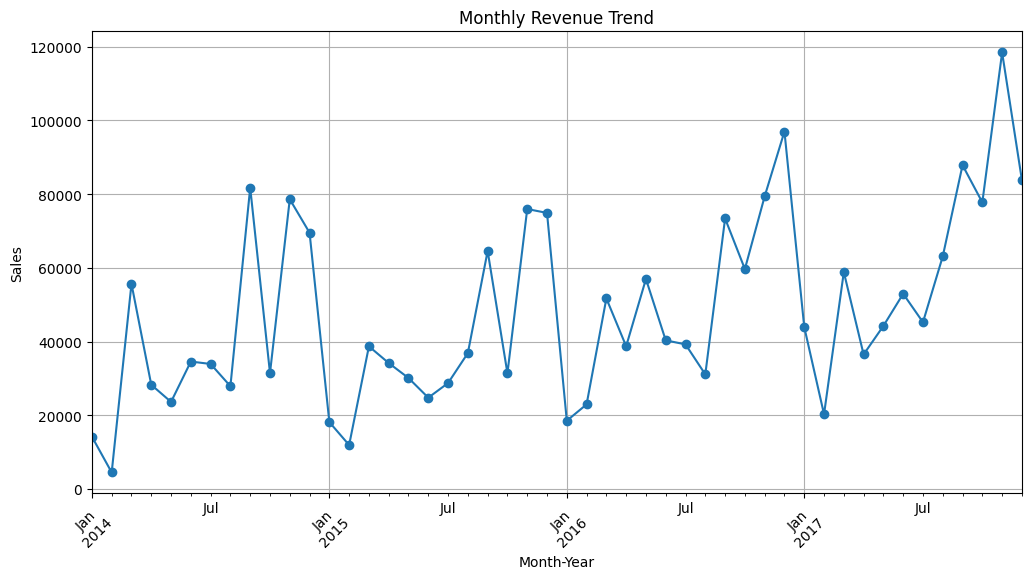

In [16]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

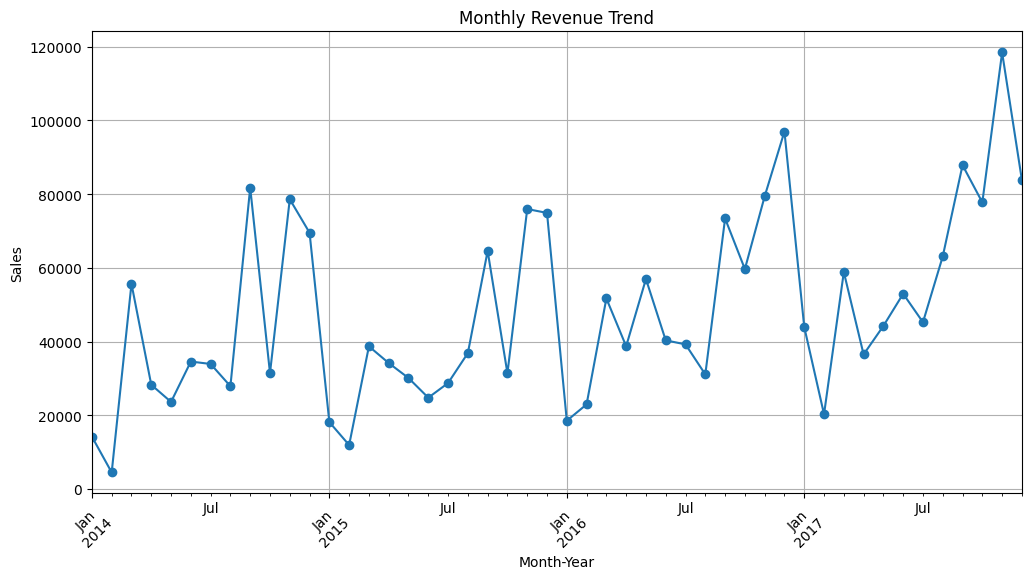

In [17]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/monthly_sales.png")

plt.show()

In [18]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(top_products.head(10))

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


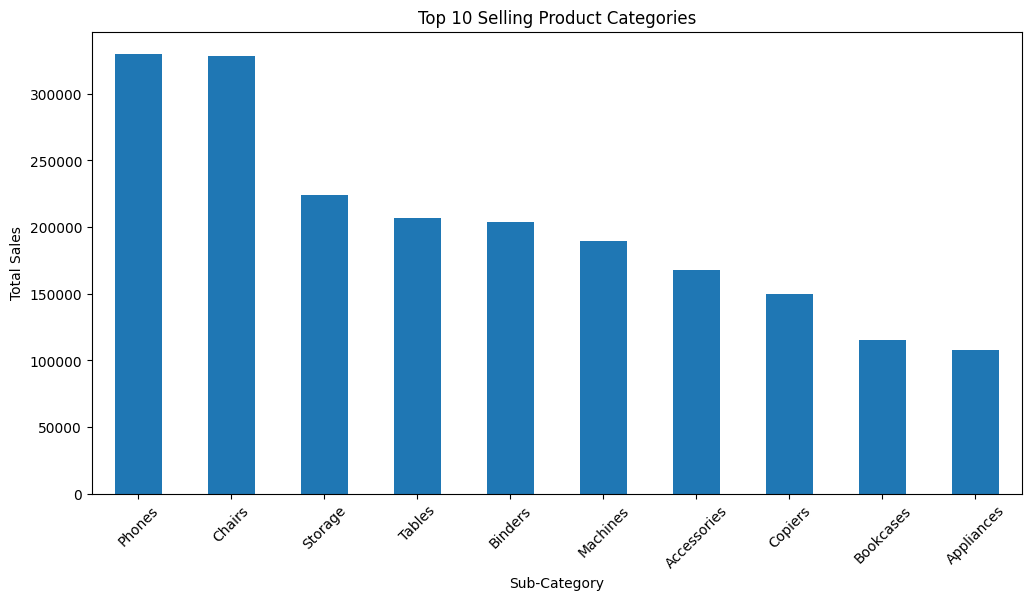

In [19]:
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Selling Product Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/top_products.png")

plt.show()

In [20]:
profit_category = df.groupby('Category')['Profit'].sum()

print(profit_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


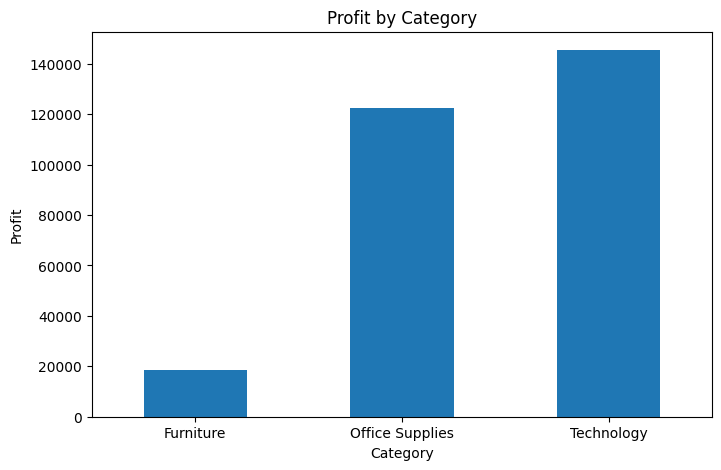

In [21]:
plt.figure(figsize=(8,5))

profit_category.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/profit_analysis.png")

plt.show()

In [22]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


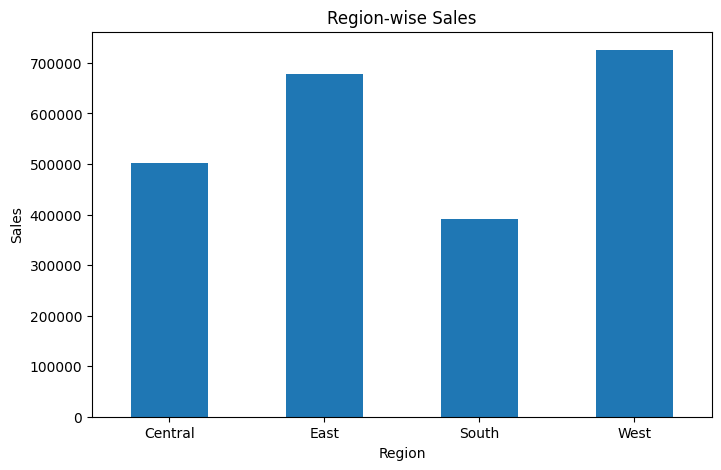

In [23]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/region_sales.png")


plt.show()

In [24]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


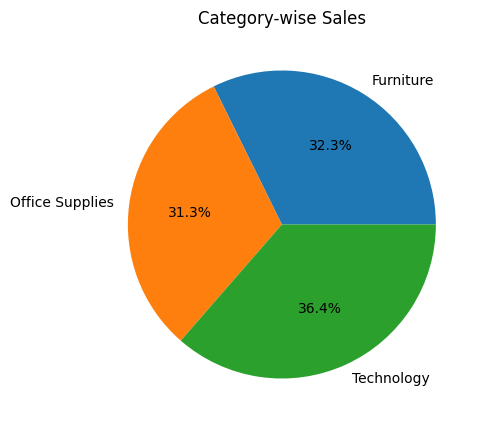

In [25]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Category-wise Sales")

plt.ylabel("")

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/category_sales.png")


plt.show()

In [26]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

print(top_customers.head(10))

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


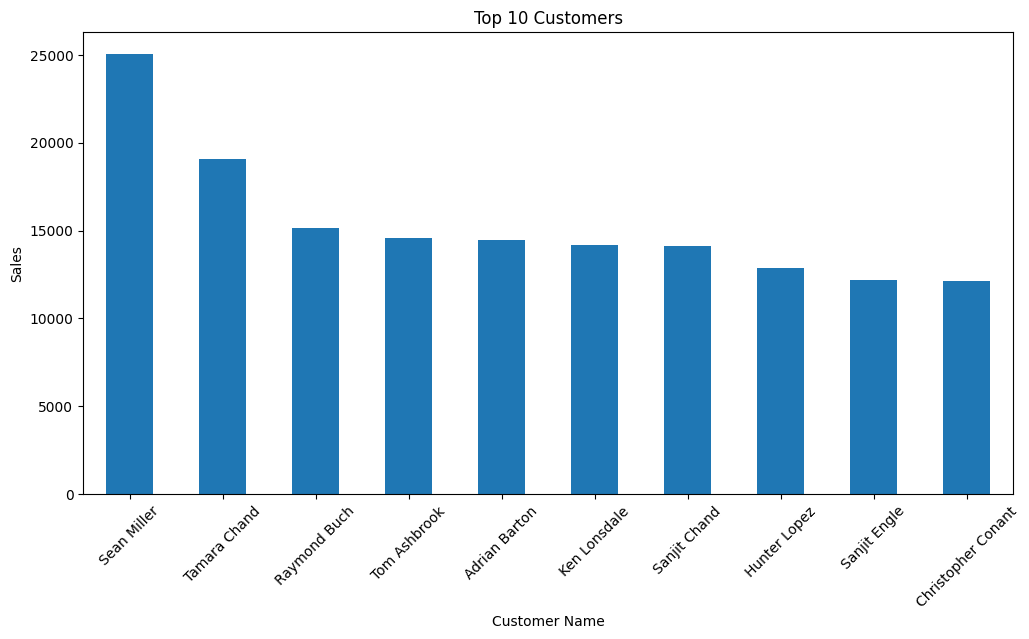

In [27]:
plt.figure(figsize=(12,6))

top_customers.head(10).plot(kind='bar')

plt.title("Top 10 Customers")
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.savefig("C:/Users/YUG/OneDrive - charusat.edu.in/Desktop/synent-task5-salesanalysis-yug/images/top_customer.png")

plt.show()

Key Insights
1. Monthly Sales Trend : 
Sales fluctuate over time ,
Some months show higher revenue growth
2. Top Products : 
Technology-related products contribute most sales ,
Low-performing categories need improvement
3. Profit Analysis :
Some categories generate high sales but low profit ,
Profit optimization is important
4. Region Analysis :
Certain regions contribute more revenue ,
Business expansion can focus on high-performing regions